In [11]:
import pandas as pd
import numpy as np
import json
import time
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, average_precision_score, RocCurveDisplay
from torch.utils.data import Dataset, DataLoader

In [26]:
!pip install openai==0.28

Defaulting to user installation because normal site-packages is not writeable
  Attempting uninstall: openai
    Found existing installation: openai 1.71.0
    Uninstalling openai-1.71.0:
      Successfully uninstalled openai-1.71.0


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [2]:
df = pd.read_csv('parkinsons_disease_data.csv')

In [3]:
df.head()

,PatientID,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,...,FunctionalAssessment,Tremor,Rigidity,Bradykinesia,PosturalInstability,SpeechProblems,SleepDisorders,Constipation,Diagnosis,DoctorInCharge
0,3058,85,0,3,1,19.619878,0,5.108241,1.380660,3.893969,...,1.572427,1,0,0,0,0,0,0,0,DrXXXConfid
1,3059,75,0,0,2,16.247339,1,6.027648,8.409804,8.513428,...,4.787551,0,1,0,1,0,1,0,1,DrXXXConfid
2,3060,70,1,0,0,15.368239,0,2.242135,0.213275,6.498805,...,2.130686,1,0,0,0,1,0,1,1,DrXXXConfid
3,3061,52,0,0,0,15.454557,0,5.997788,1.375045,6.715033,...,3.391288,1,1,1,0,0,0,1,1,DrXXXConfid
4,3062,87,0,0,1,18.616042,0,9.775243,1.188607,4.657572,...,3.200969,0,0,0,1,0,1,0,0,DrXXXConfid


In [6]:
df.iloc[:,[1,9,23,24,25,26,27,28,33]]

,Age,DietQuality,UPDRS,MoCA,FunctionalAssessment,Tremor,Rigidity,Bradykinesia,Diagnosis
0,85,3.893969,6.458713,29.181289,1.572427,1,0,0,0
1,75,8.513428,37.306703,12.332639,4.787551,0,1,0,1
2,70,6.498805,67.838170,29.927783,2.130686,1,0,0,1
3,52,6.715033,52.964696,21.304268,3.391288,1,1,1,1
4,87,4.657572,21.804880,8.336364,3.200969,0,0,0,0
...,...,...,...,...,...,...,...,...,...
2100,87,5.947278,187.887925,28.634010,8.076254,1,0,0,0
2101,67,4.825187,172.325253,13.106537,1.665751,0,0,0,1
2102,65,0.334244,111.851581,26.527734,4.785614,0,0,0,1
2103,61,9.598513,144.474453,19.873404,8.378979,1,0,1,1


In [5]:
# view count of person diagnosed with Parkinson or not
df['Diagnosis'].value_counts()

Diagnosis
1    1304
0     801
Name: count, dtype: int64

In [8]:
# prepare data for prompting
tremor_dict = { '0':'no Tremor', '1':'has Tremor'}
rigidity_dict = { '0':'no Rigidity', '1':'has Rigidity'}
bradykinesia_dict = { '0':'no Bradykinesia', '1':'has Bradykinesia'}
df['tremor_condition'] = df['Tremor'].astype(str).replace(tremor_dict)
df['rigidity_condition'] = df['Rigidity'].astype(str).replace(rigidity_dict)
df['bradykinesia_condition'] = df['Bradykinesia'].astype(str).replace(bradykinesia_dict)

In [9]:
df.head()

,PatientID,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,...,Bradykinesia,PosturalInstability,SpeechProblems,SleepDisorders,Constipation,Diagnosis,DoctorInCharge,tremor_condition,rigidity_condition,bradykinesia_condition
0,3058,85,0,3,1,19.619878,0,5.108241,1.380660,3.893969,...,0,0,0,0,0,0,DrXXXConfid,has Tremor,no Rigidity,no Bradykinesia
1,3059,75,0,0,2,16.247339,1,6.027648,8.409804,8.513428,...,0,1,0,1,0,1,DrXXXConfid,no Tremor,has Rigidity,no Bradykinesia
2,3060,70,1,0,0,15.368239,0,2.242135,0.213275,6.498805,...,0,0,1,0,1,1,DrXXXConfid,has Tremor,no Rigidity,no Bradykinesia
3,3061,52,0,0,0,15.454557,0,5.997788,1.375045,6.715033,...,1,0,0,0,1,1,DrXXXConfid,has Tremor,has Rigidity,has Bradykinesia
4,3062,87,0,0,1,18.616042,0,9.775243,1.188607,4.657572,...,0,1,0,1,0,0,DrXXXConfid,no Tremor,no Rigidity,no Bradykinesia


In [41]:
class DiagnosisDataset(Dataset):
    def __init__(self, df):
        self.df = df

    def __len__(self):
        return len(self.df)

    def __getitem__(self, index):
        column_names = [
            ("UPDRS", "The patient's Unified Parkinson's Disease Rating Scale is "),
            ("tremor_condition", ", "),
            ("rigidity_condition", " and "),
            ("MoCA", ". The patient's Montreal Cognitive score is "),
            ("FunctionalAssessment", " and Functional assessment of "),
            ("Age", ". The patient age is "),
            ("bradykinesia_condition", " and "),
            ("DietQuality", " with diet quality score of ")
        ]

        x_strs = [f"{col_desc}{self.df.iloc[index][col]}" for col, col_desc in column_names]
        x_str = ''.join(x_strs)
        x_str = x_str.replace('\n', '')
        x_str = 'Decide in a single word as yes or no, if a patient has Parkinson disease or not. '+x_str
        x_str = x_str+'. Has the patient a Parkinson disease? '

        return x_str

In [15]:
df_outcome = df['Diagnosis']
# drop 'PatientID', 'Diagnosis' and 'DoctorInCharge' for analysis

df_input = df.drop(columns=['PatientID', 'Gender', 'PosturalInstability', 'SpeechProblems','SleepDisorders','Constipation','FamilyHistoryParkinsons', 'TraumaticBrainInjury','Hypertension','Diabetes', 'Depression','Stroke','Diagnosis', 'BMI', 'Smoking','DoctorInCharge','Ethnicity','EducationLevel','BMI', 'AlcoholConsumption','PhysicalActivity','SleepQuality','SystolicBP','DiastolicBP','CholesterolTotal','CholesterolLDL','CholesterolHDL','CholesterolTriglycerides'])
df_input.head()

,Age,DietQuality,UPDRS,MoCA,FunctionalAssessment,Tremor,Rigidity,Bradykinesia,tremor_condition,rigidity_condition,bradykinesia_condition
0,85,3.893969,6.458713,29.181289,1.572427,1,0,0,has Tremor,no Rigidity,no Bradykinesia
1,75,8.513428,37.306703,12.332639,4.787551,0,1,0,no Tremor,has Rigidity,no Bradykinesia
2,70,6.498805,67.838170,29.927783,2.130686,1,0,0,has Tremor,no Rigidity,no Bradykinesia
3,52,6.715033,52.964696,21.304268,3.391288,1,1,1,has Tremor,has Rigidity,has Bradykinesia
4,87,4.657572,21.804880,8.336364,3.200969,0,0,0,no Tremor,no Rigidity,no Bradykinesia


In [16]:
# split data into training and test (80:20)
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df_input, df_outcome, test_size=0.2, random_state=42)


In [17]:
# check distribution of data in test and train
y_train.value_counts()

Diagnosis
1    1033
0     651
Name: count, dtype: int64

In [18]:
y_test.value_counts()

Diagnosis
1    271
0    150
Name: count, dtype: int64

In [42]:
test_ds = DiagnosisDataset(X_test)

In [ ]:
import openai

openai.api_key = 'sk-proj-SmtuQC32_ZoFKNrcjgBb-PiylHhAPRB3OhHydSt4U7LsAG0aBqUwA9VRQPb2uXpcPvsbYprI9CT3BlbkFJANeWULm54' 

In [33]:
response = openai.ChatCompletion.create(
  model="gpt-4o",
  messages=[
        {"role": "user", "content": "Decide in a single word if a patient has Parkinson disease or not. The patient's Unified Parkinson's Disease Rating Scale is 134.18767999357723, no Tremor and no Rigidity. The patient's Montreal Cognitive score is 3.090828018174472 and Functional assessment of 8.408278937875528. The patient age is 53 and no Bradykinesia with diet quality score of  2.088943810923467. Has the patient a Parkinson disease? "},
    ]
)

print(response.choices[0].message['content'])

No.


In [43]:
result_dict = {'no': 0, 'yes':1}
results = []
for prompt in tqdm(test_ds):
    response = openai.ChatCompletion.create(
        model="gpt-4o",
        messages=[
              {"role": "user", "content": prompt},
          ]
      )
    # change response to 0 and 1
    gpt_result = response.choices[0].message['content'].lower()
    results.append(result_dict[gpt_result.replace(".","")])
    time.sleep(1)

100%|████████████████████████████████████████████████████████████████████████████████| 421/421 [11:00<00:00,  1.57s/it]


In [45]:
auroc = roc_auc_score(y_test, results)
auprc = average_precision_score(y_test, results)
print('\nAUROC:', auroc, '\nAUPRC', auprc)


AUROC: 0.6379212792127922 
AUPRC 0.7145132417050073


In [46]:
def generate_embeddings(texts, model="text-embedding-ada-002"):
    embeddings = []
    for text in tqdm(texts):
        text = text.replace("\n", " ")
        response = openai.Embedding.create(input = [text], model=model)['data']
        embeddings.append(response[0]['embedding'])
    return np.array(embeddings)

In [47]:
train_ds = DiagnosisDataset(X_train)

embeddings = generate_embeddings(train_ds)

100%|██████████████████████████████████████████████████████████████████████████████| 1684/1684 [08:10<00:00,  3.43it/s]


In [48]:
np.shape(embeddings)

(1684, 1536)

In [49]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(embeddings, y_train)

LogisticRegression(max_iter=1000)

In [53]:
train_pred = model.predict_proba(embeddings)[:,1]
train_auroc = roc_auc_score(y_train, train_pred)
train_auprc = average_precision_score(y_train, train_pred)
print('\nAUROC:', train_auroc, '\nAUPRC', train_auprc)


AUROC: 0.8748042701451189 
AUPRC 0.9096902464816948


### Test performance

In [51]:
test_embeddings = generate_embeddings(test_ds)

test_pred = model.predict_proba(test_embeddings)[:,1]
auroc = roc_auc_score(y_test, test_pred)
auprc = average_precision_score(y_test, test_pred)
print('\nAUROC:', auroc, '\nAUPRC', auprc)

100%|████████████████████████████████████████████████████████████████████████████████| 421/421 [01:52<00:00,  3.76it/s]


AUROC: 0.8298646986469865 
AUPRC 0.9019026691280176


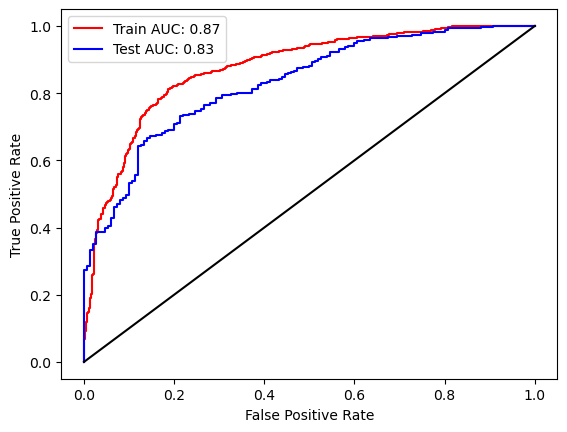

In [54]:
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score

llm_fpr_train, llm_tpr_train, llm_thresholds_train = roc_curve(y_train, train_pred)
llm_fpr_test, llm_tpr_test, llm_thresholds_test = roc_curve(y_test, test_pred)


thresh = 0.5

llm_auc_train = roc_auc_score(y_train, train_pred)
llm_auc_test = roc_auc_score(y_test, test_pred)

plt.plot(llm_fpr_train, llm_tpr_train,'r-',label = 'Train AUC: %.2f'%llm_auc_train)
plt.plot(llm_fpr_test, llm_tpr_test,'b-',label = 'Test AUC: %.2f'%llm_auc_test)
plt.plot([0,1],[0,1],'-k')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()